<a href="https://colab.research.google.com/github/mp-codez/probability-statistics-experiments/blob/solution/confidence_interval_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [2]:
train_titanic_url = "https://github.com/mp-codez/dataset/blob/main/titanic/train.csv?raw=true"
test_titanic_url = "https://github.com/mp-codez/dataset/blob/main/titanic/test.csv?raw=true"

In [3]:
train_df = pd.read_csv(train_titanic_url) # having servived column
test_df = pd.read_csv(test_titanic_url)   # dont have servived column

In [4]:
df = pd.concat([train_df.drop(columns=['Survived']), test_df]).sample(1309)  # we are using here sample to suffle the data and so order of the rows will changed

<Axes: ylabel='Density'>

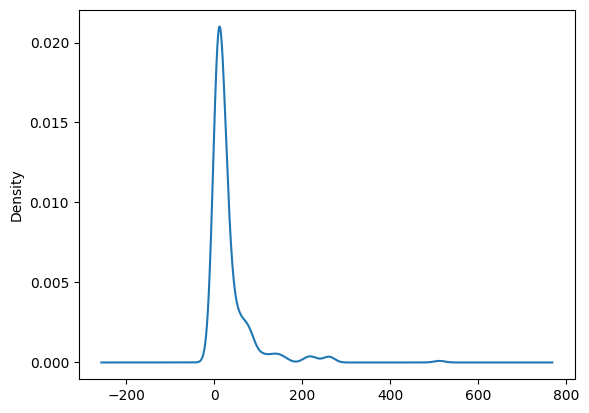

In [6]:
df['Fare'].plot(kind='kde')

In [7]:
# sample size = 30 -> 10 times
samples = []
std = []
for i in range(10):
  x = df['Fare'].dropna().sample(50).values
  std.append(x.std())
  samples.append(x.tolist())

In [11]:
samples = np.array(samples)

In [13]:
sampling_mean = samples.mean(axis=1)

In [16]:
sample_std = np.mean(std)

In [19]:
# At confidence Label : 95%
lower_limit = sampling_mean.mean() - 2.045*(sample_std/np.sqrt(30))
upper_limit = sampling_mean.mean() + 2.045*(sample_std/np.sqrt(30))

In [20]:
print("The range is", lower_limit, '-', upper_limit)

The range is 15.822340285482511 - 48.62210971451749


In [22]:
# At confidence Label : 50%
lower_limit = sampling_mean.mean() - .683*(sample_std/np.sqrt(30))
upper_limit = sampling_mean.mean() + .683*(sample_std/np.sqrt(30))

In [23]:
print("The range is", lower_limit, '-', upper_limit)

The range is 26.744904090456995 - 37.699545909543005


In [21]:
df['Fare'].dropna().mean()

np.float64(33.29547928134557)